# Chapter 1: Your First Ten-Minute Analysis

*Data Analytics with Python and Jupyter Notebook*

Run each cell in order with **Shift + Enter**. The questions we want to answer about the Bean There coffee shops (January to March 2026):

1. How much revenue did the business make in total?
2. Which store sells the most?
3. Which products are most popular?
4. Is the business growing month over month?

## Step 1: Import the tools

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## Step 2: Load the data

In [2]:
sales = pd.read_csv("../data/bean_there_sales.csv", parse_dates=["date"])
sales.head()

,date,store,product,category,quantity,unit_price,revenue
0,2026-01-01,Downtown,Espresso,Coffee,30,3.00,90.00
1,2026-01-01,Downtown,Latte,Coffee,53,4.50,238.50
2,2026-01-01,Downtown,Cappuccino,Coffee,35,4.25,148.75
3,2026-01-01,Downtown,Cold Brew,Coffee,14,4.75,66.50
4,2026-01-01,Downtown,Croissant,Bakery,26,3.25,84.50


## Step 3: Get to know the data

In [3]:
sales.shape

(1620, 7)

In [4]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1620 non-null   datetime64[us]
 1   store       1620 non-null   str           
 2   product     1620 non-null   str           
 3   category    1620 non-null   str           
 4   quantity    1620 non-null   int64         
 5   unit_price  1620 non-null   float64       
 6   revenue     1620 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(1), str(3)
memory usage: 88.7 KB


In [5]:
sales.describe()

,date,quantity,unit_price,revenue
count,1620,1620.000000,1620.000000,1620.000000
mean,2026-02-14 12:00:00,25.510494,3.783333,99.329568
min,2026-01-01 00:00:00,4.000000,2.950000,14.750000
25%,2026-01-23 00:00:00,18.000000,3.000000,61.312500
50%,2026-02-14 12:00:00,24.000000,3.750000,85.500000
75%,2026-03-09 00:00:00,31.000000,4.500000,126.000000
max,2026-03-31 00:00:00,79.000000,4.750000,355.500000
std,NaN,10.820246,0.737151,53.301466


## Step 4: Answer the questions

### Q1. Total revenue

In [6]:
total = sales["revenue"].sum()
print(f"Total revenue: ${total:,.2f}")

Total revenue: $160,913.90


### Q2. Revenue by store

In [7]:
by_store = sales.groupby("store")["revenue"].sum().sort_values(ascending=False)
by_store

store
Downtown      70205.3
University    50570.4
Riverside     40138.2
Name: revenue, dtype: float64

### Q3. Most popular products

In [8]:
popular = sales.groupby("product")["quantity"].sum().sort_values(ascending=False)
popular

product
Latte               10558
Cappuccino           7295
Croissant            6600
Cold Brew            6042
Espresso             5905
Blueberry Muffin     4927
Name: quantity, dtype: int64

### Q4. Monthly revenue

In [9]:
monthly = sales.groupby(sales["date"].dt.to_period("M"))["revenue"].sum()
monthly

date
2026-01    51411.20
2026-02    50254.75
2026-03    59247.95
Freq: M, Name: revenue, dtype: float64

In [10]:
monthly.pct_change().round(3) * 100

date
2026-01     NaN
2026-02    -2.2
2026-03    17.9
Freq: M, Name: revenue, dtype: float64

## Step 5: Visualize

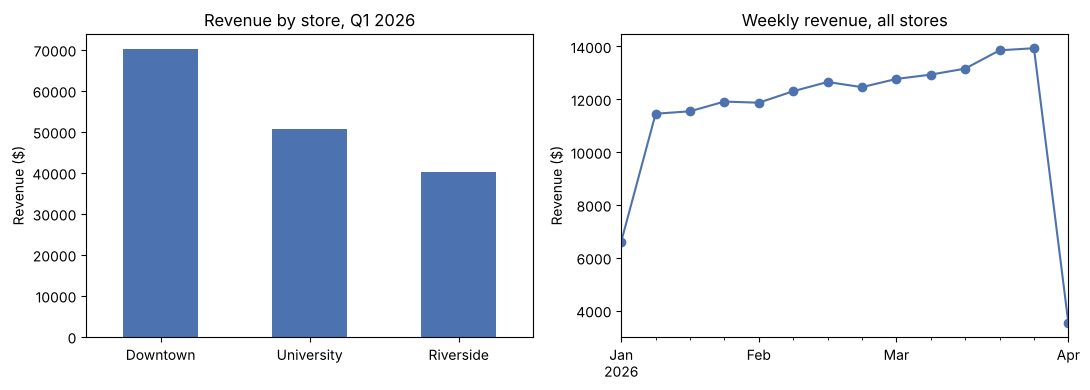

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

by_store.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Revenue by store, Q1 2026")
axes[0].set_ylabel("Revenue ($)")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

weekly = sales.set_index("date")["revenue"].resample("W").sum()
weekly.plot(ax=axes[1], marker="o", color="#4C72B0")
axes[1].set_title("Weekly revenue, all stores")
axes[1].set_ylabel("Revenue ($)")
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

**Look closely at the line chart.** The first and last points drop sharply. Did sales really crash? No. 1 January 2026 was a Thursday, so the first "week" only holds 4 days, and the last week only holds 2 days of March. Charts can mislead even when the code is correct, so always ask whether a pattern is real or an artifact of how you grouped the data. Exercise 6 asks you to fix it.

## Step 6: Write down what you found

Double-click this cell and replace the text with your own summary. For example:

- Total Q1 revenue was about \$161,000.
- Downtown is the strongest store, earning roughly 44% of revenue.
- Lattes are the best seller by a wide margin.
- March revenue was up about 18% on February.

## Exercises

1. Which **category** (Coffee or Bakery) earns more revenue?
2. What was the single best day for revenue across all stores? *Hint:* group by `date`, then use `.idxmax()`.
3. Find the best-selling product **at each store**. *Hint:* `sales.groupby(["store", "product"])["quantity"].sum()`.
4. Cold Brew sales seem to rise over the quarter. Check by computing Cold Brew quantity per month.
5. Change the bar chart to show **quantity** instead of revenue. Does the ranking of stores change?
6. Fix the weekly chart so it ignores the partial first and last weeks. *Hint:* `weekly.iloc[1:-1]`.